# Cadeias de Markov – Sensor IoT

## 1. Uma rede IoT possui 5 estados de operação para um sensor inteligente:

- **Estado 0** → Sensor totalmente operacional    
- **Estado 1** → Sensor com pequena degradação   
- **Estado 2** → Sensor com falha moderada   
- **Estado 3** → Sensor en modo crítico    
- **Estado 4** → Sensor queimado (falha total)   

O **estado 4 é absorvente**, pois após a queima do sensor ele não retorna ao
funcionamento.

## A cada ciclo de operação, o sensor pode:

- permanecer no mesmo estado,
- degradar para um estado pior,
- ou sofrer recuperação parcial (exceto no estado 4).

## As probabilidades de transição são dadas abaixo:

### Do estado 0:
- 0 → 0 com probabilidad **0.7**  
- 0 → 1 com probabilidad **0.3**

### Do estado 1:
- 1 → 0 com probabilidad **0.2**  
- 1 → 1 com probabilidad **0.5**  
- 1 → 2 com probabilidad **0.3**

### Do estado 2:
- 2 → 1 com probabilidad **0.1**  
- 2 → 2 com probabilidad **0.5**  
- 2 → 3 com probabilidad **0.4**

### Do estado 3:
- 3 → 3 com probabilidad **0.6**  
- 3 → 4 com probabilidad **0.4**

### Do estado 4:
- 4 → 4 com probabilidad **1.0** (estado absorvente)

---

## Pede-se

a) Desenhar o diagrama de transição de estados.  
b) Montar a matriz de transição da cadeia de Markov.  
c) Considerando que o sensor inicia no estado 0, calcular a probabilidade de o sensor  
atingir o estado de falha total exatamente no 4º ciclo.  
d) Determinar a matriz fundamental da cadeia.  
e) Calcular o número médio de ciclos até a absorção.  
f) Determinar a probabilidade de absorção no estado de falha total para cada estado inicial.  
g) Implementar um código em Python para:
- simular a cadeia de Markov,
- calcular as probabilidades,
- plotar o grafo de transições,
- e mostrar a evolução temporal das probabilidades dos estados.  

<a href="https://colab.research.google.com/github/jgocana/Trabalhos-TP-547/blob/master/Trabalho%204/markov.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [20]:
!pip install numpy
!pip install matplotlib
!pip install networkx


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
# ╔══════════════════════════════════════════════════════════╗
# ║              Imports e Matriz de Transição               ║
# ╚══════════════════════════════════════════════════════════╝

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

# Matriz de transição P onde P[i,j] representa a probabilidade
# de transição do estado i para o estado j em um ciclo
P = np.array([
    [0.7, 0.3, 0.0, 0.0, 0.0],  # Do estado 0: permanece(0.7), vai p/1(0.3)
    [0.2, 0.5, 0.3, 0.0, 0.0],  # Do estado 1: volta p/0(0.2), permanece(0.5), vai p/2(0.3)
    [0.0, 0.1, 0.5, 0.4, 0.0],  # Do estado 2: volta p/1(0.1), permanece(0.5), vai p/3(0.4)
    [0.0, 0.0, 0.0, 0.6, 0.4],  # Do estado 3: permanece(0.6), vai p/4(0.4)
    [0.0, 0.0, 0.0, 0.0, 1.0],  # Do estado 4: absorvente, permanece sempre(1.0)
])

print("b) Matriz de transição P:")
print(P)

b) Matriz de transição P:
[[0.7 0.3 0.  0.  0. ]
 [0.2 0.5 0.3 0.  0. ]
 [0.  0.1 0.5 0.4 0. ]
 [0.  0.  0.  0.6 0.4]
 [0.  0.  0.  0.  1. ]]


In [22]:
# ╔══════════════════════════════════════════════════════════╗
# ║             Probabilidades: itens c), d), e), f)         ║
# ╚══════════════════════════════════════════════════════════╝

# ── c) Probabilidade de atingir o estado 4 exatamente no 4º ciclo ──
# Elevamos a matriz P à potência 4 para obter as probabilidades
# de transição em exatamente 4 ciclos. O elemento P^4[0,4]
# fornece a probabilidade de partir do estado 0 e chegar ao estado 4
# exatamente no 4º ciclo.
P4 = np.linalg.matrix_power(P, 4)
print("c) Probabilidade de atingir o estado 4 exatamente no 4º ciclo")
print(f"   P(X₄=4 | X₀=0) = P^4[0,4] = {round(P4[0, 4], 6)}")

# ── d) Matriz fundamental N = (I - Q)⁻¹ ──
# Para cadeias de Markov absorventes, separamos a matriz P em:
#   Q: submatriz dos estados transientes entre si (estados 0,1,2,3)
#   R: submatriz das transições dos estados transientes ao absorvente (estado 4)
# A matriz fundamental N = (I - Q)⁻¹ indica o número esperado de vezes
# que a cadeia visita cada estado transiente j, dado que inicia no estado i.
Q = P[:4, :4]  # Submatriz 4x4 dos estados transientes
R = P[:4, 4:]  # Submatriz 4x1 das transições para o estado absorvente

N = np.linalg.inv(np.eye(4) - Q)  # Matriz fundamental

print("\nd) Matriz fundamental N = (I - Q)⁻¹:")
print(np.round(N, 4))

# ── e) Número médio de ciclos até a absorção ──
# O vetor t = N·1 fornece o número médio de ciclos que o sensor
# permanece em funcionamento (estados transientes) antes de ser absorvido
# pelo estado 4 (queimado), para cada estado inicial possível.
t = N @ np.ones(4)
print("\ne) Número médio de ciclos até a absorção por estado inicial:")
for i, ti in enumerate(t):
    print(f"   Partindo do estado {i}: {ti:.2f} ciclos em média")

# ── f) Probabilidade de absorção no estado 4 ──
# O vetor B = N·R fornece a probabilidade de o sensor ser absorvido
# pelo estado 4 (falha total), para cada estado inicial.
# Como estado 4 é o único absorvente, todas as probabilidades devem ser 1.
B = N @ R
print("\nf) Probabilidade de absorção no estado 4 por estado inicial:")
for i, bi in enumerate(B):
    print(f"   Partindo do estado {i}: {bi[0]:.6f}")

c) Probabilidade de atingir o estado 4 exatamente no 4º ciclo
   P(X₄=4 | X₀=0) = P^4[0,4] = 0.0144

d) Matriz fundamental N = (I - Q)⁻¹:
[[6.1111 4.1667 2.5    2.5   ]
 [2.7778 4.1667 2.5    2.5   ]
 [0.5556 0.8333 2.5    2.5   ]
 [0.     0.     0.     2.5   ]]

e) Número médio de ciclos até a absorção por estado inicial:
   Partindo do estado 0: 15.28 ciclos em média
   Partindo do estado 1: 11.94 ciclos em média
   Partindo do estado 2: 6.39 ciclos em média
   Partindo do estado 3: 2.50 ciclos em média

f) Probabilidade de absorção no estado 4 por estado inicial:
   Partindo do estado 0: 1.000000
   Partindo do estado 1: 1.000000
   Partindo do estado 2: 1.000000
   Partindo do estado 3: 1.000000


Histórico de estados simulados:
[0, 0, 1, 2, 2, 2, 2, 1, 2, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
Estado final após 30 ciclos: 4


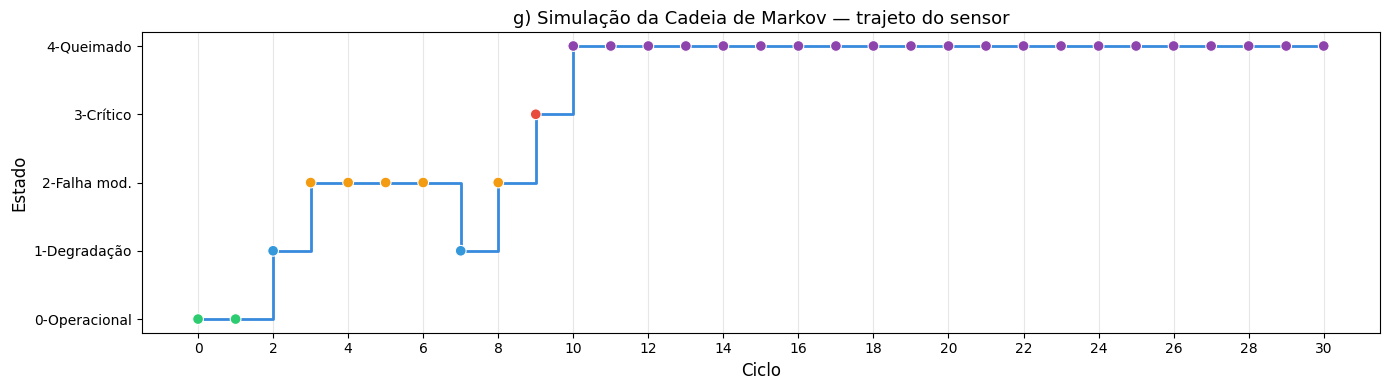

In [23]:
# ╔══════════════════════════════════════════════════════════╗
# ║                  g) Simulação da Cadeia                  ║
# ╚══════════════════════════════════════════════════════════╝

# Fixamos a semente para garantir reprodutibilidade dos resultados
np.random.seed(42)

# Parâmetros da simulação
estado_atual = 0   # Sensor inicia totalmente operacional (estado 0)
num_ciclos   = 30  # Número de ciclos de operação simulados
historico    = [estado_atual]

# A cada ciclo, o próximo estado é sorteado de acordo com
# a linha da matriz P correspondente ao estado atual
for _ in range(num_ciclos):
    proximo = np.random.choice(5, p=P[estado_atual])
    historico.append(proximo)
    estado_atual = proximo

print("Histórico de estados simulados:")
print(historico)
print(f"Estado final após {num_ciclos} ciclos: {historico[-1]}")

# Cores e rótulos para identificar visualmente cada estado no gráfico
cores_estados = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#8e44ad']
rotulos = ['0-Operacional', '1-Degradação', '2-Falha mod.', '3-Crítico', '4-Queimado']

# Gráfico do trajeto simulado:
# A linha em degraus mostra a evolução do estado ao longo dos ciclos.
# Os pontos coloridos identificam o estado em cada instante.
plt.figure(figsize=(14, 4))
plt.step(range(len(historico)), historico, where='post',
         color='#378ADD', linewidth=2, zorder=2)
plt.scatter(range(len(historico)), historico,
            c=[cores_estados[s] for s in historico],
            zorder=5, s=60, edgecolors='white', linewidths=0.8)

plt.xlabel("Ciclo", fontsize=12)
plt.ylabel("Estado", fontsize=12)
plt.title("g) Simulação da Cadeia de Markov — trajeto do sensor", fontsize=13)
plt.yticks([0,1,2,3,4], rotulos)
plt.xticks(range(0, num_ciclos + 2, 2))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

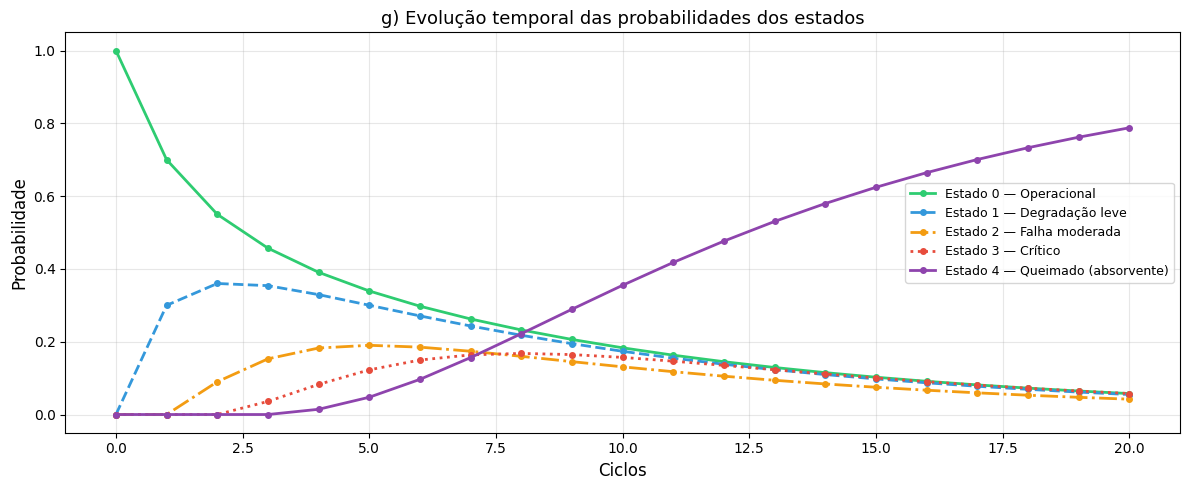

In [24]:
# ╔══════════════════════════════════════════════════════════╗
# ║           g) Evolução temporal das probabilidades        ║
# ╚══════════════════════════════════════════════════════════╝

# O vetor inicial representa o sensor partindo com certeza do estado 0
prob_inicial   = np.array([1.0, 0.0, 0.0, 0.0, 0.0])
n_passos       = 20
probabilidades = [prob_inicial]

# A cada passo, multiplicamos o vetor de probabilidades pela matriz P:
#   π(n+1) = π(n) · P
# Isso fornece a distribuição de probabilidade dos estados após n ciclos.
for _ in range(n_passos):
    probabilidades.append(probabilidades[-1] @ P)

probabilidades = np.array(probabilidades)

# Configurações visuais do gráfico
cores_plot  = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#8e44ad']
estilos     = ['-', '--', '-.', ':', '-']
rotulos_est = [
    'Estado 0 — Operacional',
    'Estado 1 — Degradação leve',
    'Estado 2 — Falha moderada',
    'Estado 3 — Crítico',
    'Estado 4 — Queimado (absorvente)',
]

# Gráfico da evolução temporal:
# Cada curva mostra como a probabilidade de estar em cada estado
# evolui ao longo dos ciclos. Espera-se que a probabilidade do
# estado 4 convirja para 1, pois é o único estado absorvente.
plt.figure(figsize=(12, 5))
for estado in range(5):
    plt.plot(probabilidades[:, estado],
             label=rotulos_est[estado],
             color=cores_plot[estado],
             linestyle=estilos[estado],
             linewidth=2,
             marker='o', markersize=4)

plt.xlabel("Ciclos", fontsize=12)
plt.ylabel("Probabilidade", fontsize=12)
plt.title("g) Evolução temporal das probabilidades dos estados", fontsize=13)
plt.legend(loc='center right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

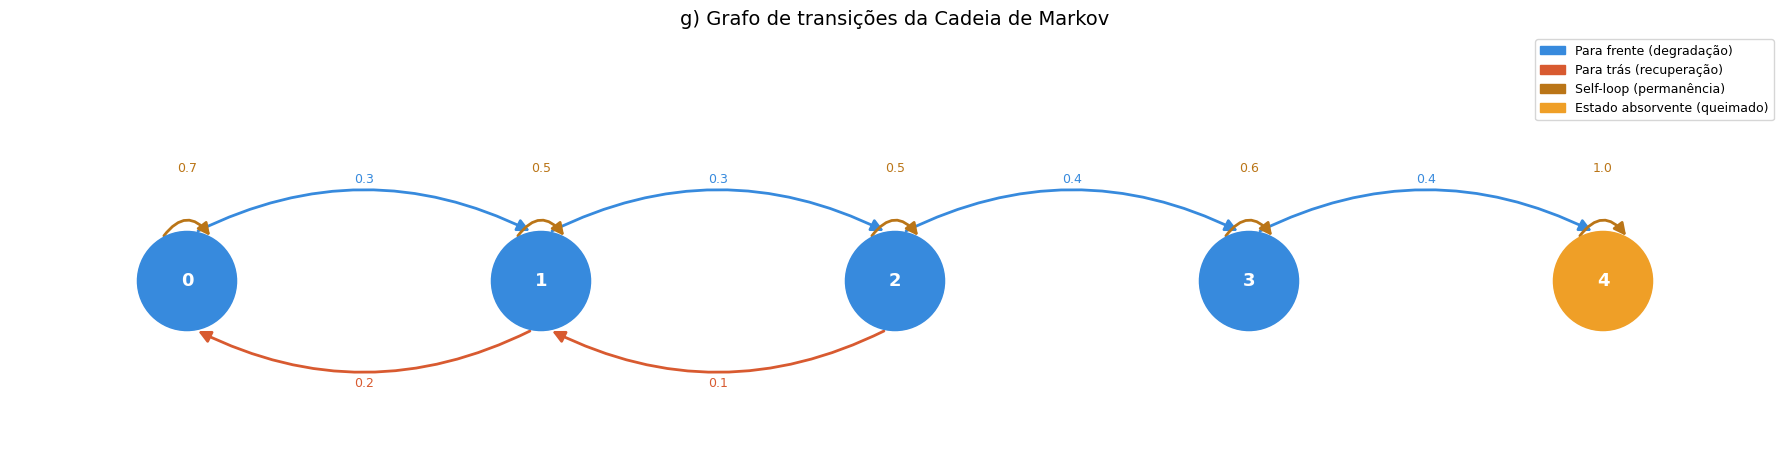

In [27]:
# ╔══════════════════════════════════════════════════════════╗
# ║               g) Grafo de transições (item a)            ║
# ╚══════════════════════════════════════════════════════════╝

# Cores que diferenciam visualmente o tipo de transição
COR_FORWARD  = "#378ADD"  # Azul  — transições para estado pior (degradação)
COR_BACKWARD = "#D85A30"  # Coral — transições para estado melhor (recuperação)
COR_LOOP     = "#BA7517"  # Âmbar — permanência no mesmo estado (self-loop)
COR_ABS      = "#EF9F27"  # Laranja — estado absorvente (queimado)

# Posições fixas dos nós ao longo do eixo horizontal
pos  = {0: (1,0), 1: (3,0), 2: (5,0), 3: (7,0), 4: (9,0)}
R_no = 0.28  # Raio do nó em unidades do sistema de coordenadas do plot

fig, ax = plt.subplots(figsize=(18, 6))
ax.set_xlim(0, 10)
ax.set_ylim(-1.0, 1.4)
ax.set_aspect('equal')
ax.axis("off")

def draw_arrow(ax, x1, y1, x2, y2, rad, color):
    """Desenha uma seta curva entre dois pontos usando FancyArrowPatch.
    O parâmetro rad controla o grau e sentido da curvatura."""
    ax.add_patch(FancyArrowPatch(
        posA=(x1, y1), posB=(x2, y2),
        connectionstyle=f"arc3,rad={rad}",
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=2,
        color=color,
    ))

def ponto_no_circulo(cx, cy, angulo_graus):
    """Calcula as coordenadas de um ponto na borda do nó circular,
    dado o ângulo em graus, para que as setas partam/cheguem
    exatamente na borda do círculo e não no seu centro."""
    a = np.radians(angulo_graus)
    return cx + R_no * np.cos(a), cy + R_no * np.sin(a)

# ── Transições para frente (degradação): curva acima dos nós ──
# As setas partem do topo (~80°) e chegam no topo (~100°) do nó destino,
# formando arcos acima da linha de nós.
for i in range(5):
    for j in range(5):
        if P[i, j] > 0 and i < j:
            x1, _ = pos[i]; x2, _ = pos[j]
            sx, sy = ponto_no_circulo(x1, 0, 80)
            tx, ty = ponto_no_circulo(x2, 0, 100)
            draw_arrow(ax, sx, sy, tx, ty, rad=-0.25, color=COR_FORWARD)
            # A altura do label escala com a distância entre os nós
            # para evitar sobreposição com o arco
            dist   = x2 - x1
            peak_y = 0.28 + 0.13 * dist
            ax.text((x1+x2)/2, peak_y, str(round(P[i,j],2)),
                    ha='center', va='bottom', fontsize=9, color=COR_FORWARD)

# ── Transições para trás (recuperação): curva abaixo dos nós ──
# As setas partem da base (~-100°) e chegam na base (~-80°) do nó destino,
# formando arcos abaixo da linha de nós, sem se sobrepor às de degradação.
for i in range(5):
    for j in range(5):
        if P[i, j] > 0 and i > j:
            x1, _ = pos[i]; x2, _ = pos[j]
            sx, sy = ponto_no_circulo(x1, 0, -100)
            tx, ty = ponto_no_circulo(x2, 0, -80)
            draw_arrow(ax, sx, sy, tx, ty, rad=-0.25, color=COR_BACKWARD)
            dist   = x1 - x2
            peak_y = -0.28 - 0.13 * dist
            ax.text((x1+x2)/2, peak_y, str(round(P[i,j],2)),
                    ha='center', va='top', fontsize=9, color=COR_BACKWARD)

# ── Self-loops (permanência no mesmo estado): arco acima do nó ──
# As setas partem e chegam no mesmo nó, formando um arco compacto
# no topo do círculo para não interferir com as demais transições.
for i in range(5):
    if P[i, i] > 0:
        x, y = pos[i]
        sx, sy = ponto_no_circulo(x, y, 120)
        tx, ty = ponto_no_circulo(x, y, 60)
        ax.add_patch(FancyArrowPatch(
            posA=(sx, sy), posB=(tx, ty),
            connectionstyle="arc3,rad=-0.7",
            arrowstyle="-|>",
            mutation_scale=18,
            linewidth=2,
            color=COR_LOOP,
        ))
        ax.text(x, y + 0.60, str(round(P[i,i],2)),
                ha='center', va='bottom', fontsize=9, color=COR_LOOP)

# ── Nós desenhados por último para ficarem sobre as setas ──
# O estado 4 recebe cor diferente por ser absorvente.
for i, (x, y) in pos.items():
    cor = COR_ABS if i == 4 else COR_FORWARD
    ax.add_patch(plt.Circle((x, y), R_no, color=cor, zorder=5))
    ax.text(x, y, str(i), ha='center', va='center',
            color='white', fontweight='bold', fontsize=13, zorder=6)

# ── Legenda ──
ax.legend(handles=[
    mpatches.Patch(color=COR_FORWARD,  label="Para frente (degradação)"),
    mpatches.Patch(color=COR_BACKWARD, label="Para trás (recuperação)"),
    mpatches.Patch(color=COR_LOOP,     label="Self-loop (permanência)"),
    mpatches.Patch(color=COR_ABS,      label="Estado absorvente (queimado)"),
], loc="upper right", fontsize=9)

plt.title("g) Grafo de transições da Cadeia de Markov", fontsize=14)
plt.tight_layout()
plt.show()